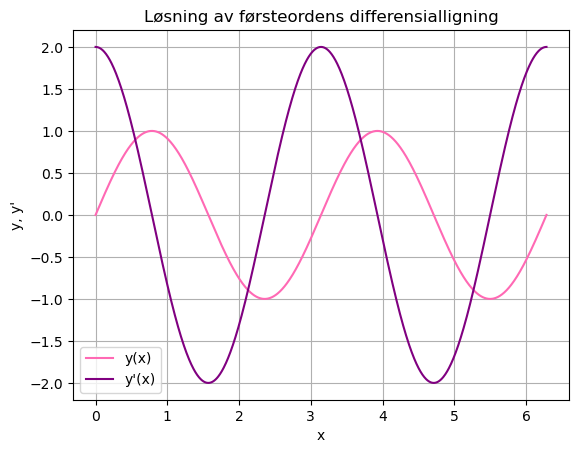

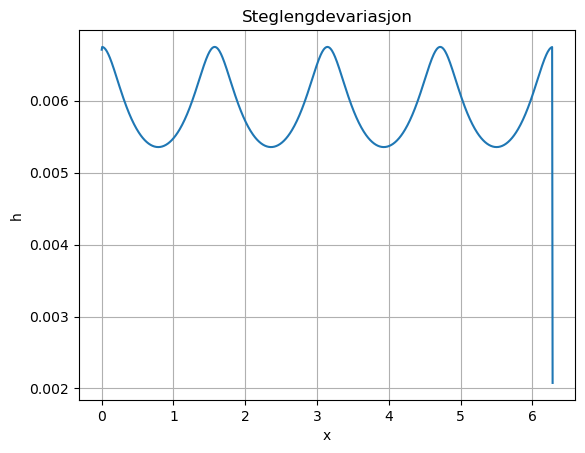

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

def solve_rk(f, x_init, x_end, y_init, h0, tol, alpha):
    n = 0
    x_list = [x_init]
    y_list = [y_init]
    h_list = []

    x = x_init
    y = np.array(y_init)
    h = h0

    while x < x_end:

        if x + h > x_end:
            h = x_end - x

        k1 = f(x, y)
        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
        est = np.linalg.norm(y_next - z_next)

        if est < tol:
            n += 1
            x += h
            y = y_next

            x_list.append(x)
            y_list.append(y)
            h_list.append(h)

            k1 = k4

        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    return np.array(x_list), np.array(y_list), np.array(h_list), n

x_init = 0.0
x_end = 2*np.pi
h0 = 0.1
tol = 10**(-7)
alpha = 0.8
y_init = np.array([0, 2])
y = y_init.copy()

x_vals, y_vals, h_vals, n = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)

y1 = y_vals[:, 0]
y2 = y_vals[:, 1]

plt.plot(x_vals, y1, label="y(x)", color = "hotpink")
plt.plot(x_vals, y2, label="y'(x)", color = "purple")
plt.xlabel("x")
plt.ylabel("y, y'")
plt.title("Løsning av førsteordens differensialligning")
plt.legend()
plt.grid()
plt.show()

plt.plot(x_vals[:-1], h_vals)
plt.title("Steglengdevariasjon")
plt.xlabel("x")
plt.ylabel("h")
plt.grid()
plt.show()